# K-Means Clustering Algorithm

## What is K-Means?

K-Means is an **unsupervised learning algorithm** used for clustering data into **K distinct groups** based on feature similarity. It groups data points such that points in the same cluster are more similar to each other than to those in other clusters.


## Objective Function

K-Means aims to minimize the within-cluster variance (WCSS):

$$
J = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

Where:
- K: number of clusters  
- Cᵢ: set of points in cluster i  
- μᵢ: centroid of cluster i  

## How It Works — Step by Step

**1. Initialization**
- Choose the number of clusters \( K \)  
- Randomly initialize \( K \) centroids  

**2. Assignment Step**
- Assign each data point to the nearest centroid:

$$
C_i = \{x : \|x - \mu_i\|^2 \leq \|x - \mu_j\|^2 \ \forall j\}
$$

**3. Update Step**
- Recalculate centroids as the mean of assigned points:

$$
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
$$

**4. Repeat**
- Repeat assignment and update steps until convergence (no change in clusters or centroids)


## Distance Metric

Most commonly uses **Euclidean Distance**:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$


## Choosing K (Elbow Method)

The optimal number of clusters is often found using the Elbow Method by plotting WCSS vs K:

- Look for the "elbow point" where the decrease in WCSS slows down  
- This point indicates a good balance between accuracy and complexity  


## Pros & Cons

| Advantages | Disadvantages |
|---|---|
| Simple and easy to implement | Requires choosing K beforehand |
| Fast and efficient | Sensitive to initial centroids |
| Scales well to large datasets | Assumes spherical clusters |
| Works well with numerical data | Affected by outliers |


## Comparison with Other Clustering Algorithms

| Algorithm | Type | Speed | Handles Shapes |
|---|---|---|---|
| K-Means | Centroid-based | Very Fast | Poor (only spherical) |
| Hierarchical | Tree-based | Slow | Good |
| DBSCAN | Density-based | Medium | Excellent |
| Gaussian Mixture | Probabilistic | Medium | Good |


## Key Takeaway

> K-Means is a **fast and widely used clustering algorithm** that groups similar data points together by minimizing intra-cluster distance. It is best suited for well-separated, spherical clusters.

The notebook begins by importing essential Python libraries required for clustering and data analysis.

[NumPy](https://numpy.org/) is used for numerical computations and handling arrays and mathematical operations.  
[Pandas](https://pandas.pydata.org/) is used for data manipulation and working with structured datasets like DataFrames.  
[Matplotlib](https://matplotlib.org/) and [Seaborn](https://seaborn.pydata.org/) are used for data visualization and plotting graphs.

[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) is used to normalize the data so that all features contribute equally to the clustering process.

[KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) is used to perform clustering by grouping data points into K clusters based on similarity.

These libraries together form the foundation for preprocessing data, scaling features, and applying the K-Means clustering algorithm.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Reading Data from CSV

In this step, the dataset is loaded into the notebook using Pandas. The `read_csv` function reads the CSV file and stores it in a DataFrame named `df`. Using `df.head()` displays the first few records, allowing an initial look at the structure and columns of the data before further analysis.

The dataset used is the Heart Disease Dataset, which can be found here: [Click here](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

In [28]:
df = pd.read_csv('cluster_data.csv')
df.head()

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [29]:
df.rename(columns={"Feature 1": "X", "Feature 2": "Y"}, inplace=True)

In [30]:
df.isnull().sum()

,0
X,0
Y,0


In [31]:
df.describe()

,X,Y
count,500.000000,500.000000
mean,1.831353,2.694970
std,4.086149,3.494165
min,-3.896491,-4.378493
25%,-1.174033,0.200712
50%,0.604212,2.807746
75%,2.750212,5.132506
max,11.867680,10.216205


In [32]:
rows , columns = df.shape
print(f"Dataset has {rows} rows & {columns} column.")

Dataset has 500 rows & 2 column.


In [33]:
df.drop_duplicates(inplace=True)

In [34]:
rows , columns = df.shape
print(f"Dataset has {rows} rows & {columns} column.")

Dataset has 500 rows & 2 column.


## Outlier Detection using IQR

In this step, the Interquartile Range (IQR) method is used to detect outliers in the dataset.

The first quartile (Q1) represents the 25th percentile, and the third quartile (Q3) represents the 75th percentile of the data.

The IQR is calculated as:

$$
IQR = Q3 - Q1
$$

Using the IQR, the bounds for detecting outliers are defined as:

$$
\text{Lower Bound} = Q1 - 1.5 \times IQR
$$

$$
\text{Upper Bound} = Q3 + 1.5 \times IQR
$$

Any data point lying below the lower bound or above the upper bound is considered an outlier.

This method helps in identifying extreme values that may affect model performance.

In [35]:
# Finding the 1st quartile & 3rd quartile and inter-quatertile range
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)

# Calculating the Inter-quartile range
iqr = q3 - q1
print(f"Inter-Quartile Range: \n{iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"\nLower Bound: \n{lower_bound}")
print(f"\nUpper Bound: \n{upper_bound}")

Inter-Quartile Range: 
X    3.924245
Y    4.931794
dtype: float64

Lower Bound: 
X   -7.060400
Y   -7.196979
dtype: float64

Upper Bound: 
X     8.636579
Y    12.530197
dtype: float64


In [36]:
# Capping the outliers
df = df.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [37]:
rows , columns = df.shape
print(f"Dataset has {rows} rows & {columns} column.")

Dataset has 500 rows & 2 column.


## Feature Scaling using StandardScaler

In this step, the dataset is standardized using StandardScaler to ensure all features are on the same scale.

Standardization transforms the data so that each feature has:
- Mean = 0  
- Standard Deviation = 1  

The transformation is given by:

$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- \( x \): original value  
- \( \mu \): mean of the feature  
- \( \sigma \): standard deviation of the feature  

The `fit_transform()` function computes the mean and standard deviation from the dataset and applies the scaling.

This step is important for distance-based algorithms like K-Means, as it ensures that no feature dominates due to its scale.

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Elbow Method for Optimal K

In this step, the Elbow Method is used to determine the optimal number of clusters (K) for K-Means.

For different values of K (from 1 to 5), the model is trained and the Within-Cluster Sum of Squares (WCSS) is calculated using `model.inertia_`.

WCSS represents the total variance within clusters:

$$
WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

The values of WCSS are plotted against K.

- As K increases, WCSS decreases  
- The optimal K is chosen at the "elbow point" where the rate of decrease sharply slows down  

This point indicates a good balance between minimizing error and avoiding unnecessary clusters.

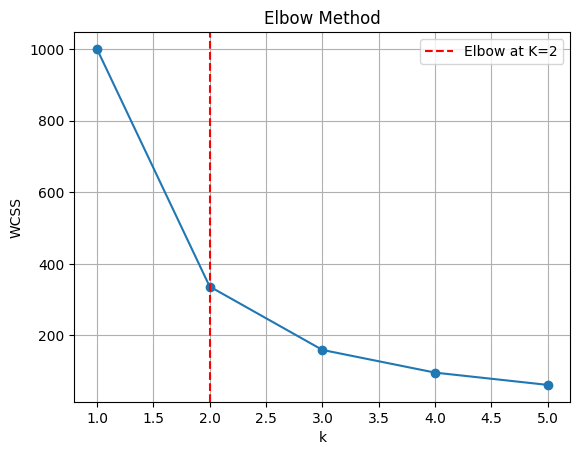

Optimal K detected: 2


In [39]:
wcss = []
K_range = range(1, 6)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

diffs1 = np.diff(wcss)
diffs2 = np.diff(diffs1)
optimal_k = int(np.argmax(diffs2) + 2)

plt.grid(True)
plt.plot(K_range, wcss, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Elbow at K={optimal_k}')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.legend()
plt.show()

print(f"Optimal K detected: {optimal_k}")

## K-Means Clustering and Cluster Assignment

In this step, the K-Means algorithm is applied with \( K = 3 \) clusters.

The model is trained on the scaled data (`X_scaled`) and assigns each data point to the nearest cluster using the `fit_predict()` function.

Each data point is labeled based on the closest centroid:

$$
C_i = \arg\min_j \|x - \mu_j\|^2
$$

The resulting cluster labels are stored in a new column `Cluster` in the dataset.

Using `df.head(10)` displays the first 10 rows with their assigned cluster labels, allowing inspection of how data points are grouped.

In [40]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head(10)

,X,Y,Cluster
0,2.698582,-0.672960,0
1,-0.128113,4.355952,0
2,2.509049,5.773146,0
3,-1.518276,3.444886,0
4,-0.072283,2.883769,0
5,8.636579,-2.022418,1
6,0.281702,4.154153,0
7,8.636579,-1.606801,1
8,1.690574,1.054368,0
9,1.575612,1.518022,0


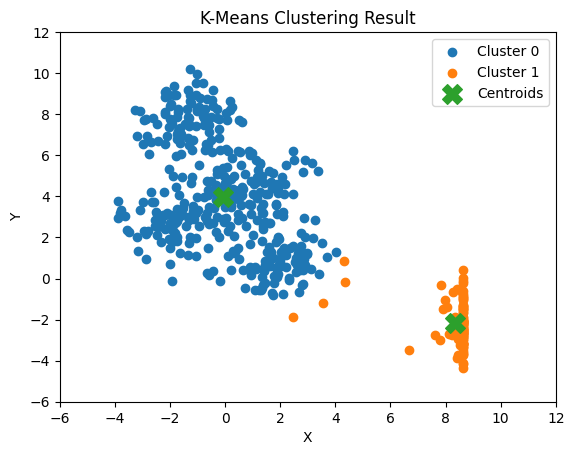

In [41]:
plt.figure()

for cluster in df["Cluster"].unique():
    subset = df[df["Cluster"] == cluster]
    plt.scatter(subset["X"], subset["Y"], label=f"Cluster {cluster}")

centroids = kmeans.cluster_centers_

centroids_original = scaler.inverse_transform(centroids)

plt.scatter(centroids_original[:, 0],
            centroids_original[:, 1],
            marker='X',
            s=200,
            label='Centroids')
plt.xlim(-6, 12)   # widen X-axis
plt.ylim(-6, 12)   # widen Y-axis

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering Result")
plt.legend()
plt.show()